In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('Housing.csv')

df.head(5).style.background_gradient(cmap='Blues')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Checking null values across columns
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
# Description of the dataset
# only describes about the numerical columns, not the categorical ones
# print(df.describe())
print(df.describe().T)

           count          mean           std        min        25%        50%  \
price      545.0  4.766729e+06  1.870440e+06  1750000.0  3430000.0  4340000.0   
area       545.0  5.150541e+03  2.170141e+03     1650.0     3600.0     4600.0   
bedrooms   545.0  2.965138e+00  7.380639e-01        1.0        2.0        3.0   
bathrooms  545.0  1.286239e+00  5.024696e-01        1.0        1.0        1.0   
stories    545.0  1.805505e+00  8.674925e-01        1.0        1.0        2.0   
parking    545.0  6.935780e-01  8.615858e-01        0.0        0.0        0.0   

                 75%         max  
price      5740000.0  13300000.0  
area          6360.0     16200.0  
bedrooms         3.0         6.0  
bathrooms        2.0         4.0  
stories          2.0         4.0  
parking          1.0         3.0  


UniVariate Analysis
analyzing only one variable at a time to understand its basic characteristics.

In [6]:
df['bedrooms'].value_counts()
# prints the range of the values and their counts like here min is 1 and max is 6 bedrooms

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64

In [7]:
df['bathrooms'].value_counts()

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

In [8]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

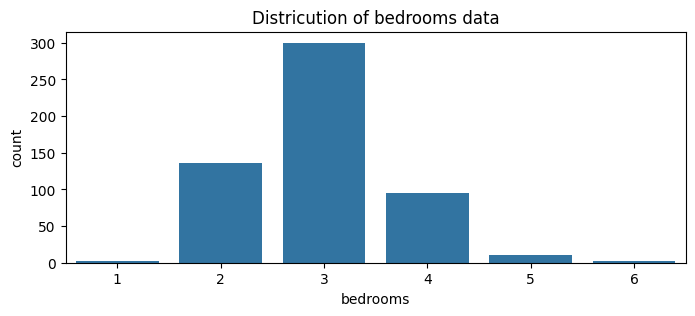

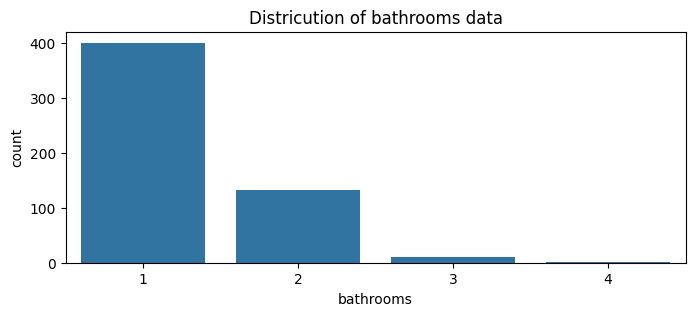

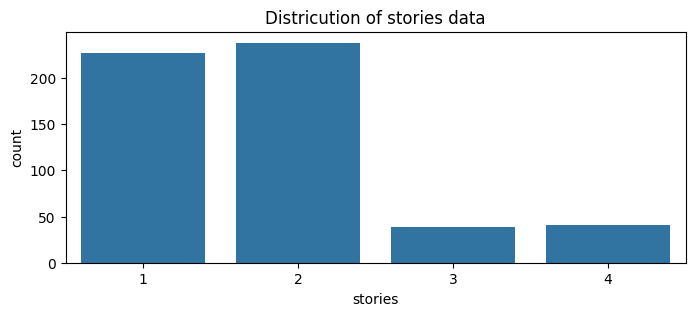

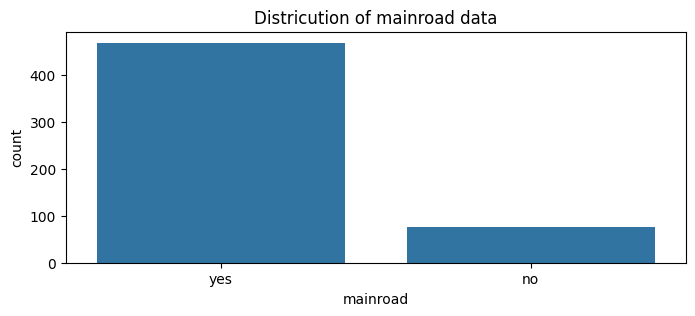

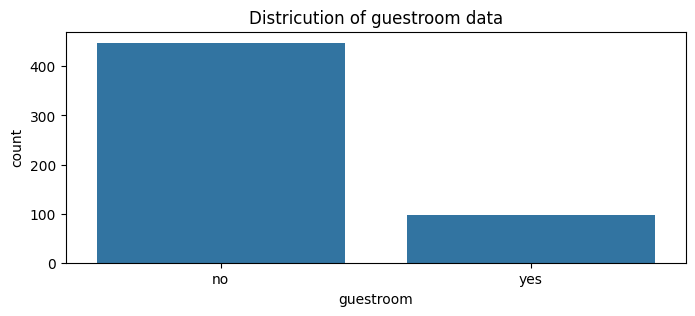

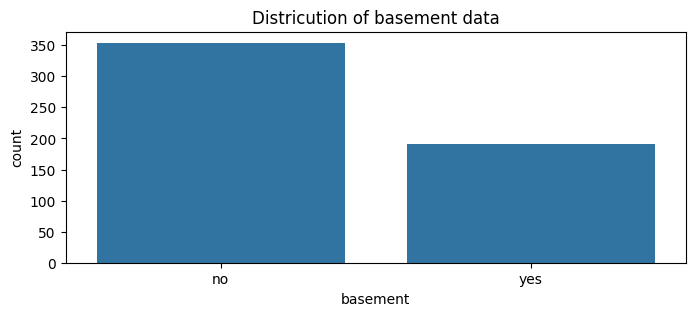

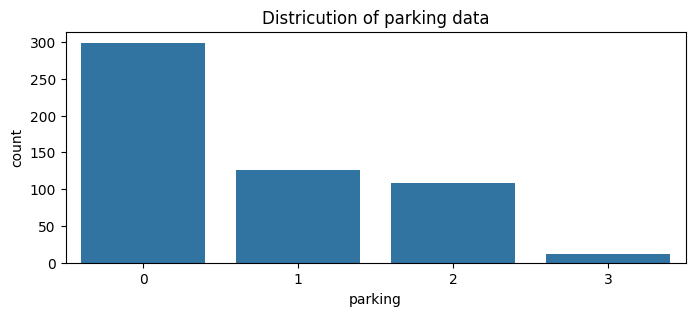

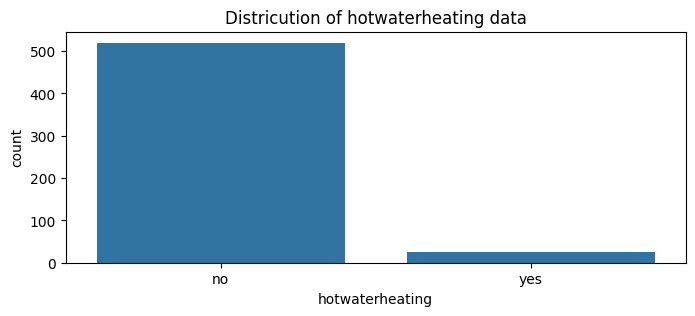

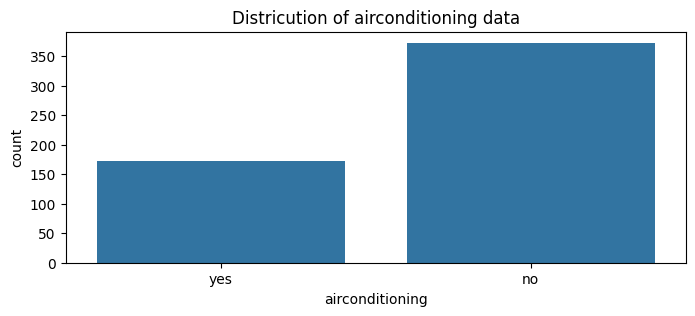

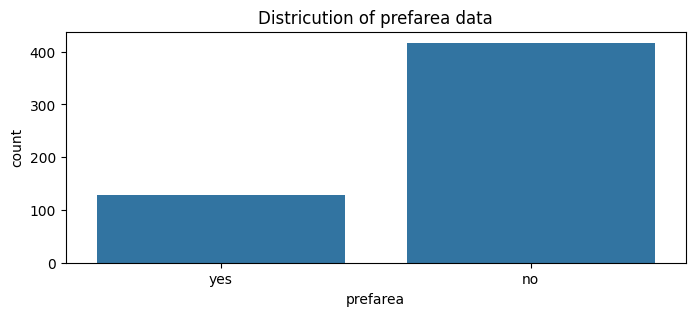

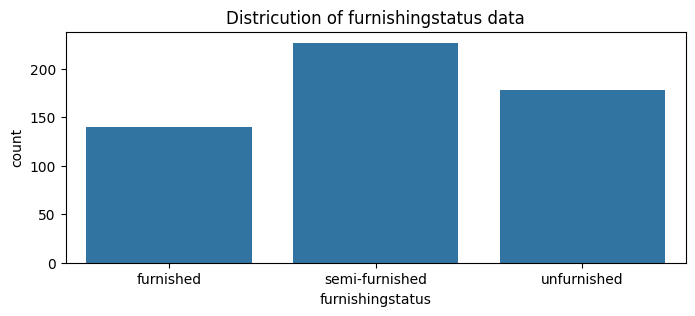

In [9]:
categorical_labels = ['bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement','parking', 'hotwaterheating', 'airconditioning','prefarea', 'furnishingstatus']
for label in categorical_labels:
    plt.figure(figsize=(8,3))
    # plt.figure() → creates a new blank figure (canvas)
    # figsize=(8,3) → sets width = 8 inches, height = 3 inches
    sns.countplot(x=label,data=df)
    # It counts occurrences of each category in column label and shows them as a bar chart.
    
    # If your data is:
    #     Gender = ["Male", "Female", "Male", "Male", "Female"]
    
    # Then:
    # sns.countplot(x="Gender", data=df)
    plt.title(f'Districution of {label} data')
    plt.show()

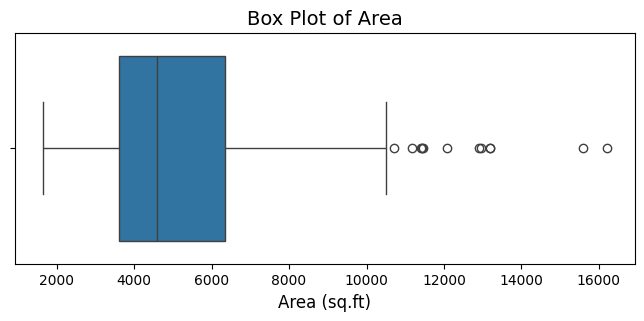

In [10]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['area'])
plt.title("Box Plot of Area",fontsize=14)
plt.xlabel("Area (sq.ft)",fontsize=12)
plt.show()


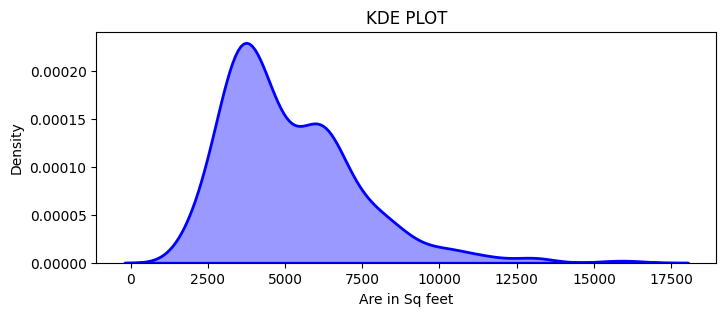

In [11]:
plt.figure(figsize=(8,3))
sns.kdeplot(df['area'],fill=True,color='blue',alpha=0.4,linewidth=2)
# 👉 df['area']
# Numerical column you’re analyzing
# Example: house area, land size, etc.

# 👉 sns.kdeplot(...)
# Creates a smooth curve showing distribution
# Helps see:
# Where values are concentrated
# Spread
# Skewness

# 👉 fill=True
# Fills the area under the curve
# Makes it easier to visually understand density
# 👉 color='blue'
# Sets curve color

# 👉 alpha=0.4
# Controls transparency
# 0 → invisible, 1 → fully solid
# 👉 0.4 = semi-transparent
# 👉 linewidth=2
# Thickness of the curve
# 👉 Bigger = bolder line
plt.title("KDE PLOT")
plt.xlabel("Are in Sq feet")
plt.ylabel("Density")
plt.show()

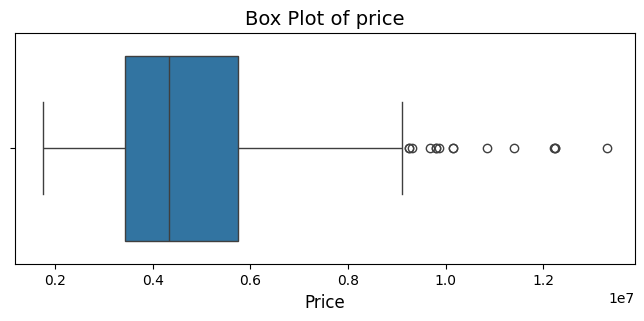

In [12]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['price'])
plt.title("Box Plot of price",fontsize=14)
plt.xlabel("Price",fontsize=12)
plt.show()


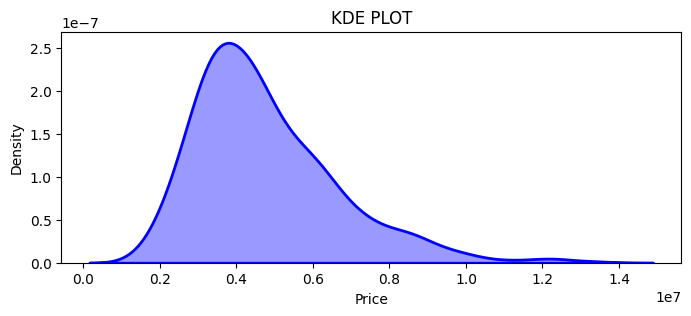

In [13]:
plt.figure(figsize=(8,3))
sns.kdeplot(df['price'],fill=True,color='blue',alpha=0.4,linewidth=2)
plt.title("KDE PLOT")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

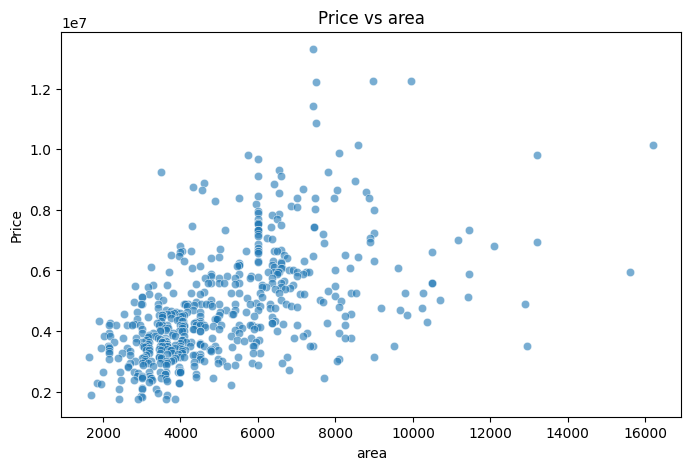

In [14]:
numeric_cols = ['area']
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col,y="price",data=df,alpha=0.6)
    # It plots points (dots) where:
    # X-axis → col (any feature, e.g., area, bedrooms)
    # Y-axis → "price"
    # Each dot = one data row


    # 🔹 Breaking it down
    # 👉 x=col
    # Feature you're comparing
    # Example: "area"
    # 👉 y="price"
    # Target variable
    # Example: house price
    # 👉 data=df
    # Your dataset
    # 👉 alpha=0.6
    # Transparency of points
    # Helps when points overlap
    # 👉 Lower = more transparent
    plt.title(f"Price vs {col}",fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

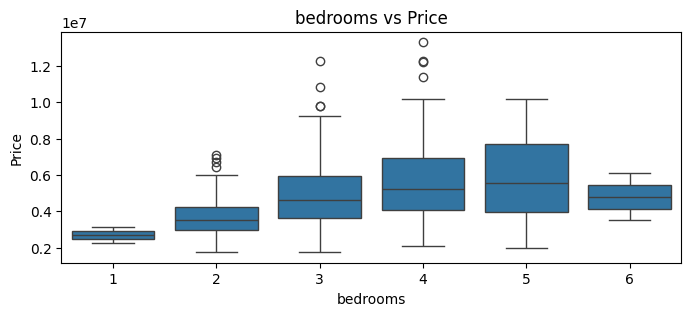

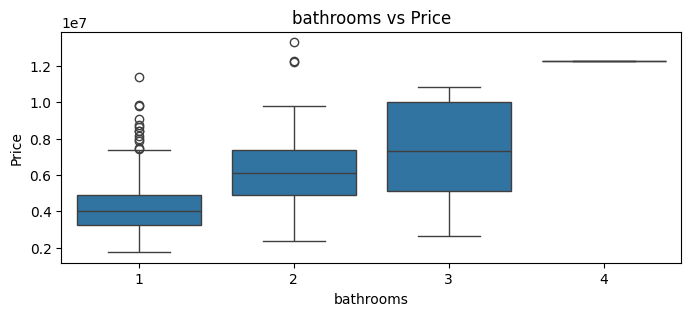

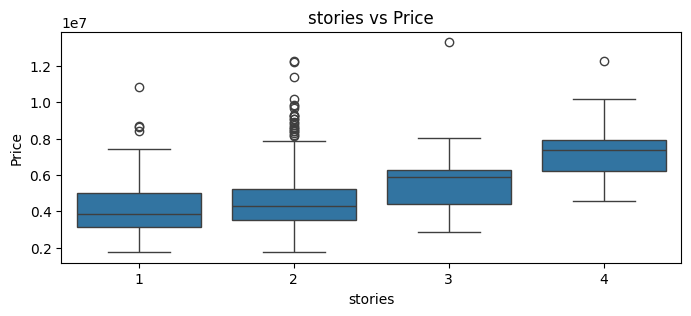

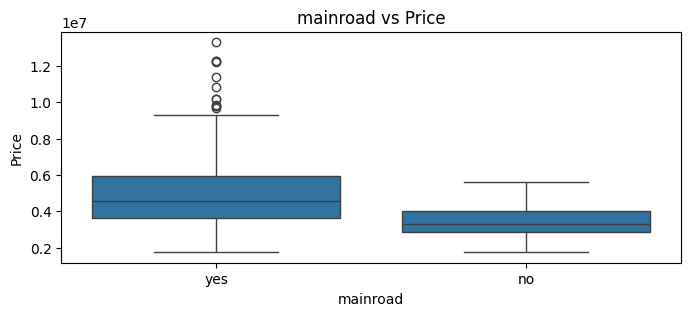

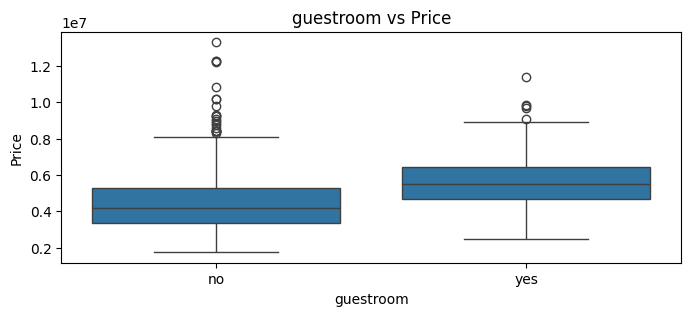

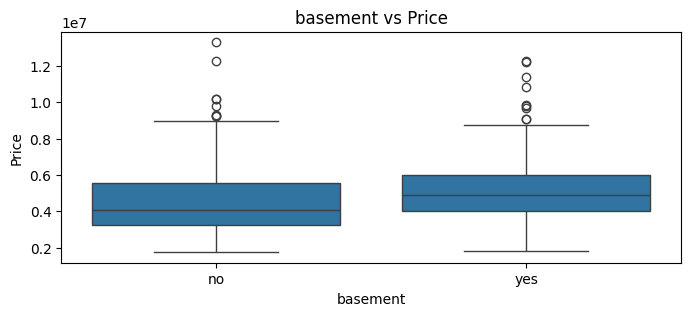

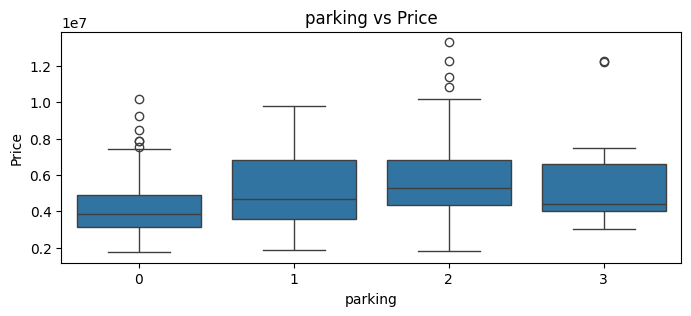

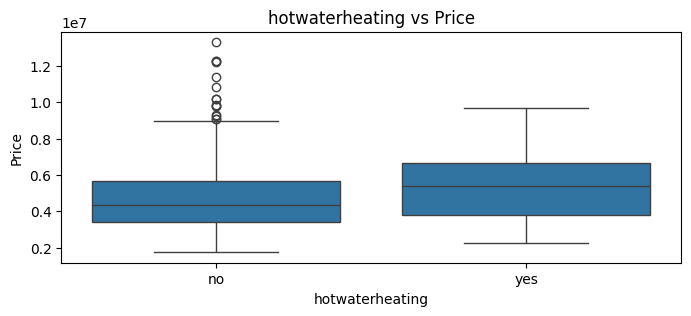

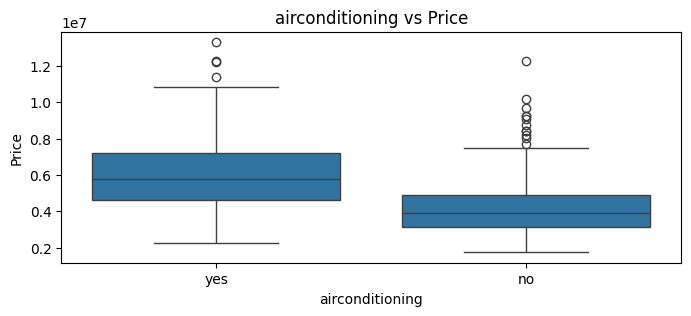

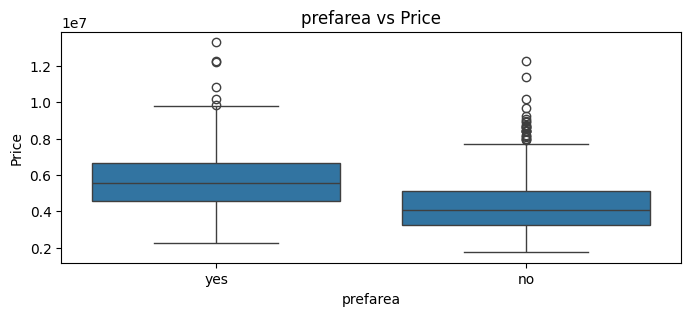

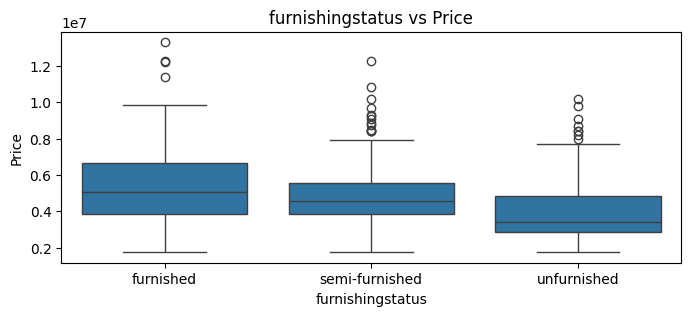

In [15]:
categorical_labels = ['bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement','parking', 'hotwaterheating', 'airconditioning','prefarea', 'furnishingstatus']
for label in categorical_labels:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=label,y="price",data=df)
    plt.title(f'{label} vs Price')
    plt.xlabel(label)
    plt.ylabel("Price")
    plt.show()